# Notebook 4 — Age-specific impact functions for heat mortality

This notebook builds **age-differentiated heat–mortality impact functions (IFs)** and links them to the daily T2M hazard and exposures produced in previous notebooks. The IFs express **excess heat deaths relative to a comfortable reference temperature (20 °C)** and are implemented in CLIMADA for pixel-wise risk calculations.

---

## 1. Inputs and setup

- Load **city** configuration, paths, and common objects from previous notebooks:
  - Daily **T2M hazard** on the UrbClim grid (`hazard_T2M_daily_rome.h5`), one event per day for 2030, 2040, 2050.
  - **Exposures** with age groups `<15`, `15–64`, `65+`, population counts, and vulnerability (`exposure_with_vulnerability_rome*.h5`).
- Repair and reattach **daily dates and frequencies** in the hazard:
  - `H.date` set from `hazard_T2M_daily_events_rome.csv`.
  - `H.frequency = 1 / (365 or 366)` so that frequencies **sum to 1 per year**.
- Compute a **city-mean daily T2M series** as a diagnostic (mean over all valid grid cells per day).

---

## 2. Constructing age-specific heat–mortality curves

- Define a **shared temperature grid**:
  - `T_grid = 0–40 °C` (step 0.5 °C), with **reference temperature** `T_ref = 20 °C`, where excess risk is around 0.
- For each age group, fit a **convex power-law tail above 20 °C**:
  - where delta D(T) is **change in deaths per 100,000 people per day**.
  - Choose approximate **anchor points** inspired by an EU-style temperature–mortality figure:
    - 65+ (“elderly”): e.g. ~0.3 per 100k at 24 °C, ~12 per 100k at 35 °C.
    - 15–64 (“adults”): ~0.1 per 100k at 28 °C, ~0.4 per 100k at 35 °C.
    - <15 (“young”): ~0.02 per 100k at 28 °C, ~0.05 per 100k at 35 °C.
  - Solve for \(\beta\) and \(p\) so the curve passes through the chosen points; curves are **monotone and convex** on the hot side.
- Convert **Δ deaths per 100k per day** to **per-person daily death probability** (mdd) for CLIMADA:
  - Interpretation:  
    d extra deaths per 100,000 people per day” ⇒ per-person probability  
  - Clip mdd values to \([0, 1]\); below 20 °C, mdd = 0 (heat-only excess).
- Result: three **age-specific response curves** mdd(T) that say:  
  *if a day has mean T2M = T, then in age group A there is an extra mdd(T) probability of dying due to heat, relative to a 20 °C day.*

---

## 3. City-level diagnostic: manual annual heat deaths

- Using **scenario [choice]** exposures for 2030, 2040, 2050:
  - Build a table of **age-group populations by year** on the T2M grid.
- For each day and age group:
  - Take the **city-mean daily temperature**.
  - Look up **Δ deaths per 100k** from the fitted curve.
  - Multiply by the **age-specific population / 100,000** to get **daily excess deaths**.
- Aggregate over days to get **annual heat-attributable deaths by age**:
  - Also compute **per-100k rates** for each age group.
- This “manual” calculation serves as a **sanity check** and is intentionally simpler:
  - Uses a single **city-mean T per day** (no spatial variation),
  - Whereas CLIMADA later uses **full gridded T2M**.

---

## 4. Implementing impact functions in CLIMADA

- Build **ImpactFunc** objects for hazard type `"T2M"`:
  - All share the same `intensity = T_grid`.
  - `mdd` is age-specific (`young_mdd`, `adult_mdd`, `elderly_mdd`).
  - `paa` (probability of asset affected) = 1 for all intensities.
  - Assign IDs:
    - `<15` → IF id 1,
    - `15–64` → IF id 2,
    - `65+` → IF id 3.
- Create an **ImpactFuncSet** and run CLIMADA’s `ImpactCalc`:
  - For each age group:
    - Copy exposures, **zero out everyone not in that age group**,
    - Set the correct **impact function ID** in the exposure,
    - Compute **impact per event** (deaths per day),
    - Aggregate by year ⇒ **annual heat deaths by age**.
- Compare CLIMADA results vs. manual city-mean results:
  - Differences arise because CLIMADA uses the **full spatial distribution of T2M** (hotter and cooler pixels), not just the city mean.
  - These CLIMADA-based annual deaths are the numbers used later in the pipeline.

---

## 5. Baseline mortality scaling (Wittgenstein / “baseline deaths”)

- Load **baseline all-cause mortality rates** per 100k by age and year (`baselinedeaths.csv`).
- Build a **baseline mortality table** for `<15`, `15–64`, `65+` in 2030, 2040, 2050.
- Compute **scale factors** relative to a reference year (2030):
  - For each age and year
- Apply these scale factors to heat-attributable deaths:
  - Optionally scale both **manual** and **CLIMADA-based** annual deaths:
    - If all-cause mortality falls in an age group, **heat mortality is assumed to fall proportionally** (and vice versa).
  - Compute **absolute deaths** and **per-100k rates**:
    - With and without baseline scaling, to show how assumptions about future vulnerability change the results.

---

## 6. Outputs for following notebooks

This notebook writes out a series of files for later use:

- **Impact function curves**
  - `if_curves_frozen_rome.json` — age-specific T2M IF curves (intensity and mdd arrays) frozen to disk.

- **Baseline and scaling metadata**
  - `baseline_heat_scaling_rome.csv` — baseline mortality scaling factors by age & year.

- **Annual heat mortality summaries (city-level)**
  - Manual (city-mean T):
    - `annual_heat_deaths_manual_rome.csv` — raw annual heat deaths by age.
    - `annual_heat_deaths_manual_scaled_rome.csv` — after baseline scaling.
  - CLIMADA (full grid):
    - `annual_heat_deaths_generic_rome.csv` — raw annual heat deaths by age.
    - `annual_heat_deaths_generic_scaled_rome.csv` — after baseline scaling.

Together, these outputs provide **age-specific, CLIMADA-compatible impact functions for heat**, plus consistent annual mortality summaries under different assumptions about future baseline vulnerability.

In [1]:
import os
os.environ["CITY"] = "genova"   # pick the city here

In [2]:
# generic bootstrap 
from pathlib import Path
import os, sys

def _find_root():
    start = Path.cwd()
    for cand in [start, *start.parents]:
        if (cand/"cityheat").is_dir() and (cand/"configs").is_dir():
            return cand
    raise RuntimeError("Repo root not found.")
ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from cityheat.nbsetup import bootstrap
from cityheat.paths import make_P, ensure_out

# choose city here
SLUG = globals().get("SLUG", os.environ.get("CITY", "rome")).lower()

C    = bootstrap(SLUG)      # reads configs/<slug>.yml and syncs that city only if wanted
CFG  = C["CFG"]; CITY = C["CITY"]
BASE = C["BASE"]; OUT = C["OUT"]; INT = C["INT"]

P    = make_P(BASE)         # read-only path helper
OUTP = ensure_out(OUT)      # write-safe path helper
print(f"→ City: {CITY}  |  BASE={BASE}  OUT={OUT}  INT={INT}")

→ City: genova  |  BASE=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova  OUT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova  INT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim


In [3]:
cfg  = C.get("cfg")     # dict loaded from YAML

**from previous notebooks**

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from climada.hazard import Hazard
from climada.entity.exposures import Exposures
from climada.entity.impact_funcs import ImpactFunc, ImpactFuncSet
from climada.engine import ImpactCalc

plt.rcParams.update({"figure.dpi": 130})

# loading hazard and exposure from previous notebooks 
# hazard (still one file, this is year-agnostic) 
haz_path = INT / f"hazard_T2M_daily_{SLUG}.h5"
H = Hazard.from_hdf5(haz_path)

# exposure loader
def load_any_exposure(SLUG=SLUG):
    """
    For IF calibration we just need some exposure with age_group and value.
    Trying a list of possible files (with/without vulnerability, scenario/year),
    and picking the first that exists.
    """
    candidates = [
        # baseline with vulnerability from NB3
        INT / f"exposure_with_vulnerability_{SLUG}.h5",
        OUT / f"exposure_with_vulnerability_{SLUG}.h5",

        # a common baseline scenario (e.g. SSP2 2030)
        INT / f"exposure_with_vulnerability_{SLUG}_SSP2_2030.h5",
        OUT / f"exposure_with_vulnerability_{SLUG}_SSP2_2030.h5",

        # legacy names kept for backward compatibility
        INT / f"exposure_people_{SLUG}.h5",
        OUT / f"exposure_people_{SLUG}.h5",
    ]

    for p in candidates:
        if p.exists():
            print(f"→ Using exposure for IF diagnostics: {p}")
            return Exposures.from_hdf5(p)

    raise FileNotFoundError(
        "No exposure HDF5 found for IF notebook. "
        "Re-run Notebook 3 so at least one exposure_with_vulnerability_*.h5 exists."
    )

exp = load_any_exposure()

# loading scenario exposures by year for population diagnostics 

SCEN = "SSP2" # choose population scenario we want 
YEARS = [2030, 2040, 2050]

def load_exposure_by_year(scen_code=SCEN, years=YEARS, SLUG=SLUG):
    """
    Loading age-differentiated exposure for each (scenario, year) from NB3 outputs.
    Files are expected to be like:
      OUT / f"exposure_with_vulnerability_{SLUG}_{scen_code}_{year}.h5"
    """
    exps = {}
    for y in years:
        p = OUT / f"exposure_with_vulnerability_{SLUG}_{scen_code}_{y}.h5"
        if not p.exists():
            raise FileNotFoundError(f"Expected exposure file not found: {p}")
        print(f"→ Loaded exposure for {scen_code} {y}: {p}")
        exps[y] = Exposures.from_hdf5(p)
    return exps

exposures_by_year = load_exposure_by_year()

# repairing daily metadata 
def _days_in_year(y):
    return 366 if (y % 4 == 0 and (y % 100 != 0 or y % 400 == 0)) else 365

def reattach_daily_dates(INT, SLUG, H):
    csv = INT / f"hazard_T2M_daily_events_{SLUG}.csv"
    df = pd.read_csv(csv).sort_values("row").reset_index(drop=True)

    n = H.intensity.shape[0]
    assert len(df) == n, f"Events CSV rows ({len(df)}) != hazard rows ({n})."

    H.event_id   = df["event_id"].to_numpy(int)
    H.date       = pd.to_datetime(df["date"]).to_numpy("datetime64[ns]")
    H.event_name = np.array([f"T2M_{d.date()}" for d in pd.to_datetime(df["date"])], dtype=object)

    yrs = pd.to_datetime(df["date"]).dt.year.to_numpy(int)
    H.frequency      = np.array([1.0/_days_in_year(y) for y in yrs], dtype=float)
    H.frequency_unit = "1/year"
    return H

H = reattach_daily_dates(INT, SLUG, H)
H.haz_type = "T2M"
H.units    = "degC (daily mean)"

H.write_hdf5(INT / f"hazard_T2M_daily_{SLUG}.h5")

yrs = pd.to_datetime(H.date).year.to_numpy(int)
print(pd.Series(yrs).value_counts().sort_index())
print(pd.DataFrame({"y": yrs, "f": H.frequency}).groupby("y")["f"].sum())

assert np.allclose(pd.DataFrame({"y": yrs, "f": H.frequency}).groupby("y")["f"].sum().values, 1.0)

if not hasattr(H, "date") or len(getattr(H, "date", [])) != H.intensity.shape[0]:
    raise RuntimeError("Daily dates not present in hazard. Re-run NB3 saving steps.")

# Event-year index from daily dates
dates = pd.to_datetime(pd.Series(H.date.astype("datetime64[ns]")))
year_idx = dates.dt.year.to_numpy(int)  # length = n_days

→ Using exposure for IF diagnostics: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/exposure_with_vulnerability_genova.h5
→ Loaded exposure for SSP2 2030: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/exposure_with_vulnerability_genova_SSP2_2030.h5
→ Loaded exposure for SSP2 2040: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/exposure_with_vulnerability_genova_SSP2_2040.h5
→ Loaded exposure for SSP2 2050: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/exposure_with_vulnerability_genova_SSP2_2050.h5
2025-12-09 18:33:06,181 - climada.hazard.io - WARNING - write_hdf5: the class member date is skipped, due to its type, ndarray, for which writing to hdf5 is not implemented. Reading this H5 file will probably lead to date being set to its default value.
2030    365
2040    366
2050    365
Name: count, dtype: int64
y
2030    1.0
2040    1.0
2050    1.0
Name: f, dtype: 

In [5]:
# H.intensity and H.fraction are sparse (events x cells)
num = H.intensity.multiply(H.fraction).sum(axis=1)   # sum of T over valid cells
den = H.fraction.sum(axis=1)                         # number of valid cells
citymean_daily = (num / den).A1                      # 1D array (length = n_days)

pd.DataFrame({"date": dates, "citymean_degC": citymean_daily}).head(10)

,date,citymean_degC
0,2030-01-01,8.760148
1,2030-01-02,8.488250
2,2030-01-03,7.352683
3,2030-01-04,7.844236
4,2030-01-05,7.884486
5,2030-01-06,8.097083
6,2030-01-07,8.739366
7,2030-01-08,8.898768
8,2030-01-09,9.024281
9,2030-01-10,9.213580


sanity plot of the daily city-mean temps

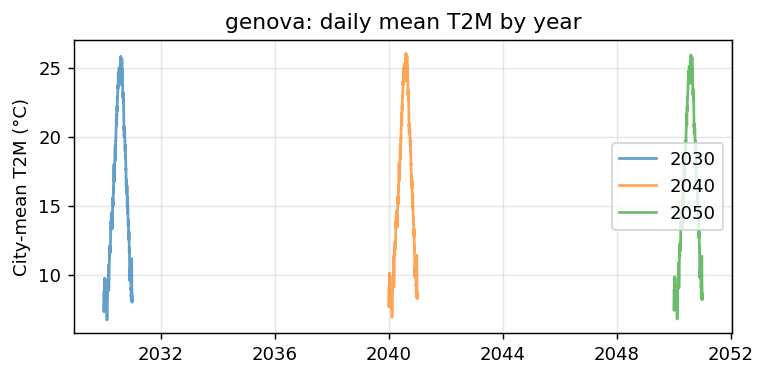

In [6]:
# daily city-mean T2M per year (just for intuition)
daily_df = pd.DataFrame({"date": dates, "citymean_degC": citymean_daily})
daily_df["year"] = daily_df["date"].dt.year

fig, ax = plt.subplots(figsize=(6,3))
for y, sub in daily_df.groupby("year"):
    ax.plot(sub["date"], sub["citymean_degC"], label=y, alpha=0.7)
ax.set_ylabel("City-mean T2M (°C)")
ax.set_title(f"{CITY}: daily mean T2M by year")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

Temperature grid for impact functions

In [7]:
# Intensity axis for all T2M impact functions (0–40 °C)
t_min, t_max, t_step = 0.0, 40.0, 0.5
T_grid = np.arange(t_min, t_max + 1e-6, t_step)  # °C
T_ref  = 20.0  # "comfortable" temperature, where excess risk is around 0

Helper to build a “heat-only” tail: change indeaths per 100k to daily probability

Approximation of each of the curve as a smooth power-law tail above 20 °C that matches a couple of points from the EU figure, then convert “extra deaths per 100,000 people per hot day” into a fraction of people dying that day.

In [8]:
def heat_tail_power(T, T_ref, d1, T1, d2, T2):
    """
    Constructing a convex 'heat-only' curve:
      change deaths per 100k = beta * (T - T_ref)^p  for T > T_ref, else 0
    passing approximately through (T1, d1) and (T2, d2).
    """
    # distance above reference
    h1 = max(T1 - T_ref, 1e-6)
    h2 = max(T2 - T_ref, 1e-6)
    # exponent from the two target points
    p = np.log(d2 / d1) / np.log(h2 / h1)
    beta = d1 / (h1 ** p)
    out = np.zeros_like(T, dtype=float)
    h = np.clip(T - T_ref, 0, None)
    out = beta * np.power(h, p)
    return out, beta, p

- I take the EU figure with change in deaths per 100k ppl per day by age
- I choose anchor points and fir a hot-side curve above 20°
- I convert extra deaths per 100k per day into a per person daily death proba (mdd)
    - Curves say : for each temp T and each age group: at this T, there are this change
      in deaths per 100,000 ppl per day more than at 20°C => d(T)
    - To turn into mdd(T) I interpret the unit: d deaths per 100,000 per day means taking
      100,000 ppl on that day at temperature T, expect d extra deaths.
      Divide by 100,000 to get per person. So d/100,000 : proba one person dies that day.
      Use mdd(T): what CLIMADA expects as mdd onIF : fractionof exposed ppl that die on
      that event/day.
      Feed to CLIMADA as mdd for each age-specifc IF.
      So mdd(T)=change deaths per 100,000 per day at T/100,000
- I plug mdd(T) curves into CLIMADA as age-specific IF
- Then I run CLIMADA with this hazard and those IFs
    - Our hazard (daily mean temperature from UrbClim for 2030, 2040, 2050)
    - One event per day with H.intensity: temp on each grid cell for that day
    - H.fration = pop mask/valid cell mask
    - H.date = actual calendar data
    - H.frequency = 1/365 or 1/366 depending on the year
    - We feed that H and age specific IF mdd(T) into CLIMADA
    - For each day and each grid cell, looks up mdd(T) for that day's temp
    - Multiplies by exposed ppl in that cell/age group
    - sums over cells and days => annual heat-attributable deaths 

We choose rough “anchor points” trying to be as close as possible to the EU panel

- Elderly: about 1 extra death/100k at around 28 °C, around 12 at around 35 °C.

- Adults: about 0.1 at 28 °C, 0.4 at 35 °C.

- Young: tiny effect, say 0.02 at 28 °C, 0.05 at 35 °C.

In [9]:
# Elderly (65+)
elderly_d, elderly_beta, elderly_p = heat_tail_power(
    T_grid, T_ref,
    d1=0.3,  T1=24.0,   # 0.3 per 100k at 24°C
    d2=12.0, T2=35.0    # 12 per 100k at 35°C
)

# Adults (15–64)
adult_d, adult_beta, adult_p = heat_tail_power(
    T_grid, T_ref,
    d1=0.10, T1=28.0,   # 0.1 per 100k at 28°C
    d2=0.40, T2=35.0    # 0.4 per 100k at 35°C
)

# Young (<15)
young_d, young_beta, young_p = heat_tail_power(
    T_grid, T_ref,
    d1=0.02, T1=28.0,   
    d2=0.05, T2=35.0
)

# converting change in deaths per 100k per day to probability per person per day (fraction)
per100k = 100_000.0
elderly_mdd = elderly_d / per100k
adult_mdd   = adult_d   / per100k
young_mdd   = young_d   / per100k

# making sure we never exceed 1 
elderly_mdd = np.clip(elderly_mdd, 0, 1)
adult_mdd   = np.clip(adult_mdd,   0, 1)
young_mdd   = np.clip(young_mdd,   0, 1)

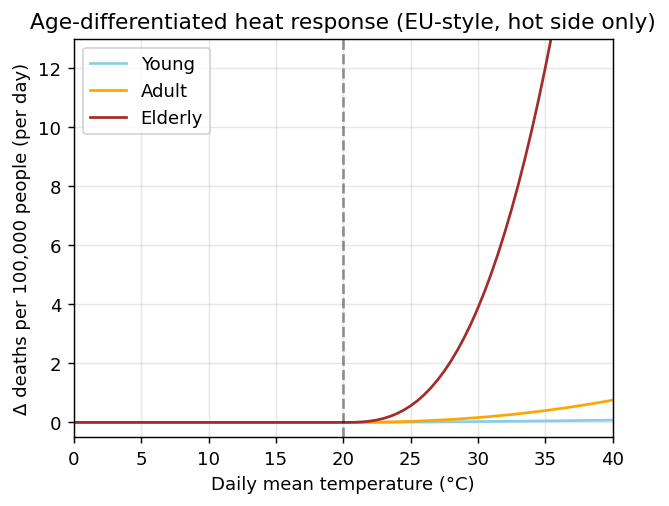

Elderly curve parameters: beta = 0.006264, p = 2.791
Adult   curve parameters: beta = 0.001019, p = 2.205
Young   curve parameters: beta = 0.0009653, p = 1.458


In [10]:
fig, ax = plt.subplots(figsize=(5,4))
ax.plot(T_grid, young_d,   label="Young",  color="skyblue")
ax.plot(T_grid, adult_d,   label="Adult",  color="orange")
ax.plot(T_grid, elderly_d, label="Elderly",color="brown")
ax.axvline(T_ref, color="k", linestyle="--", alpha=0.4)
ax.set_xlim(0, 40)
ax.set_ylim(-0.5, 13)
ax.set_xlabel("Daily mean temperature (°C)")
ax.set_ylabel("Δ deaths per 100,000 people (per day)")
ax.set_title("Age-differentiated heat response (EU-style, hot side only)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print("Elderly curve parameters: beta = %.4g, p = %.3f" % (elderly_beta, elderly_p))
print("Adult   curve parameters: beta = %.4g, p = %.3f" % (adult_beta, adult_p))
print("Young   curve parameters: beta = %.4g, p = %.3f" % (young_beta, young_p))

Age-group populations

In [11]:
# age-group populations using SSP2 projections for each year 

# building a table [year x age_group] with total population from the SSP2 exposures
age_pop_by_year = (
    pd.concat(
        {
            year: exp_y.gdf
                       .groupby("age_group")["value"]
                       .sum()
                       .astype(float)
            for year, exp_y in exposures_by_year.items()
        },
        axis=1,
    )
    .T  # years as rows
    .sort_index()
)

print(f"Population by age group (T2M grid, scenario {SCEN}):")
print(age_pop_by_year)
print("Total population per year:")
print(age_pop_by_year.sum(axis=1))

# for backwards compatibility with the existing code below, keeping a 2030 baseline vector
age_pop = age_pop_by_year.loc[2030].sort_index()
print("\nUsing 2030 age_pop as baseline for some diagnostics;")
print("full time-varying populations are in `age_pop_by_year`.")

Population by age group (T2M grid, scenario SSP2):
age_group          15-64            65+           <15
2030       334769.043136  188747.155729  53033.567462
2040       294256.490384  226141.764531  52019.405640
2050       270007.826892  240086.028982  54858.224236
Total population per year:
2030    576549.766327
2040    572417.660554
2050    564952.080110
dtype: float64

Using 2030 age_pop as baseline for some diagnostics;
full time-varying populations are in `age_pop_by_year`.


Building interpolation helpers for the curves

In [12]:
import numpy as np
import pandas as pd

# mapping age group to curve in "deaths per 100k per day"
curves_per100k = {
    "<15":   young_d,
    "15-64": adult_d,
    "65+":   elderly_d,
}

def delta_deaths_per100k(T):
    """
    Return a dict {age_group: Δ deaths per 100k per day} 
    for a scalar temperature T (°C).
    """
    out = {}
    for age, curve in curves_per100k.items():
        out[age] = float(np.interp(T, T_grid, curve))
    return out

Turning daily temps into daily excess deaths

In [13]:
# building a DataFrame with one row per day
df = pd.DataFrame({
    "date": dates,
    "temp_degC": citymean_daily,
})
df["year"] = df["date"].dt.year

rows = []
for _, row in df.iterrows():
    T = row["temp_degC"]
    y = row["year"]
    d_per100k = delta_deaths_per100k(T)
    for age in ["<15", "15-64", "65+"]:
        deaths_day = d_per100k[age] * (age_pop_by_year.loc[y, age] / 100_000.0)
        rows.append({
            "date":  row["date"],
            "year":  y,
            "age_group": age,
            "temp_degC": T,
            "delta_deaths": deaths_day,
        })

daily_heat = pd.DataFrame(rows)

In [14]:
daily_heat = pd.DataFrame(rows)

# look at the first few days
print(daily_heat.head())

        date  year age_group  temp_degC  delta_deaths
0 2030-01-01  2030       <15   8.760148           0.0
1 2030-01-01  2030     15-64   8.760148           0.0
2 2030-01-01  2030       65+   8.760148           0.0
3 2030-01-02  2030       <15   8.488250           0.0
4 2030-01-02  2030     15-64   8.488250           0.0


In [15]:
# yearly deaths by age group
yearly = (
    daily_heat
    .groupby(["year", "age_group"])["delta_deaths"]
    .sum()
    .unstack("age_group")          # columns: '<15', '15-64', '65+'
    .fillna(0.0)
)

# renaming columns 
yearly = yearly.rename(
    columns={
        "<15":   "deaths_young",
        "15-64": "deaths_adult",
        "65+":   "deaths_elderly",
    }
)

# adding total across ages
yearly["deaths_total"] = (
    yearly["deaths_young"]
    + yearly["deaths_adult"]
    + yearly["deaths_elderly"]
)

print(yearly)

age_group  deaths_adult  deaths_elderly  deaths_young  deaths_total
year                                                               
2030           6.979294       57.454041      0.357810     64.791144
2040           6.885969       79.470793      0.380314     86.737076
2050           5.951655       78.210037      0.385559     84.547251


Aggregate to annual totals and rates per 100k

In [16]:
# Annual deaths by age group
annual_by_age = (
    daily_heat
    .groupby(["year", "age_group"])["delta_deaths"]
    .sum()
    .unstack("age_group")
)

print("Annual heat deaths (absolute):")
print(annual_by_age)

# Annual rates per 100k in each age group
annual_rates_per100k = annual_by_age.copy()
for age in ["<15", "15-64", "65+"]:
    # age_pop_by_year[age] is a Series indexed by year, so this aligns correctly
    annual_rates_per100k[age] = (
        annual_by_age[age] / (age_pop_by_year[age] / 100_000.0)
    )

print("\nAnnual heat deaths per 100k, by age group:")
print(annual_rates_per100k)

Annual heat deaths (absolute):
age_group     15-64        65+       <15
year                                    
2030       6.979294  57.454041  0.357810
2040       6.885969  79.470793  0.380314
2050       5.951655  78.210037  0.385559

Annual heat deaths per 100k, by age group:
age_group     15-64        65+       <15
year                                    
2030       2.084809  30.439686  0.674686
2040       2.340125  35.142024  0.731100
2050       2.204253  32.575838  0.702828


**Into CLIMADA: pixel-wise, not city-mean anymore**

In [17]:
from climada.entity.impact_funcs import ImpactFunc, ImpactFuncSet

# making sure T_grid and *_mdd are numpy arrays
T_arr      = np.asarray(T_grid, float)
young_arr  = np.asarray(young_mdd, float)
adult_arr  = np.asarray(adult_mdd, float)
elderly_arr= np.asarray(elderly_mdd, float)

# sanity check (monotone, between 0 and 1)
for lbl, arr in [("<15", young_arr), ("15-64", adult_arr), ("65+", elderly_arr)]:
    assert np.all(arr >= 0) and np.all(arr <= 1), f"{lbl} mdd outside [0,1]"

age_ifs = {
    "<15": ImpactFunc(
        haz_type="T2M",
        id=1,
        intensity=T_arr,
        mdd=young_arr,
        paa=np.ones_like(T_arr),
        name="<15",
    ),
    "15-64": ImpactFunc(
        haz_type="T2M",
        id=2,
        intensity=T_arr,
        mdd=adult_arr,
        paa=np.ones_like(T_arr),
        name="15–64",
    ),
    "65+": ImpactFunc(
        haz_type="T2M",
        id=3,
        intensity=T_arr,
        mdd=elderly_arr,
        paa=np.ones_like(T_arr),
        name="65+",
    ),
}

ifs = ImpactFuncSet(list(age_ifs.values()))
ifs.check()  # will raise if something is inconsistent
print("Built age-specific T2M impact functions:", [f"{k}→{v.id}" for k, v in age_ifs.items()])

Built age-specific T2M impact functions: ['<15→1', '15-64→2', '65+→3']


In [18]:
from climada.engine import ImpactCalc

# mapping age label to IF id
age_to_if_id = {
    "<15": 1,
    "15-64": 2,
    "65+": 3,
}

# year index from hazard dates
year_idx = pd.to_datetime(H.date.astype("datetime64[ns]")).year

climada_annual = {}

for age_lbl in ["<15", "15-64", "65+"]:
    # copying exposures and zero out everyone not in this age group
    exp_age = exp.copy()
    mask = (exp_age.gdf["age_group"] == age_lbl)
    
    # people not in this age group to 0 persons
    exp_age.gdf.loc[~mask, "value"] = 0.0
    
    # assign the right IF id only for this age group
    exp_age.gdf["if_T2M"] = 0
    exp_age.gdf.loc[mask, "if_T2M"] = age_to_if_id[age_lbl]

    # running ImpactCalc: this returns deaths per event in this age group
    imp = ImpactCalc(exp_age, ifs, H).impact(save_mat=False)

    # aggregating to yearly totals (sum of deaths over all days in that year)
    daily_deaths = pd.Series(imp.at_event)  # one value per day/event
    annual_deaths = daily_deaths.groupby(year_idx).sum()

    climada_annual[age_lbl] = annual_deaths

In [19]:
print("Annual heat deaths (absolute):")
print(annual_by_age)

Annual heat deaths (absolute):
age_group     15-64        65+       <15
year                                    
2030       6.979294  57.454041  0.357810
2040       6.885969  79.470793  0.380314
2050       5.951655  78.210037  0.385559


In [20]:
# CLIMADA-based annual heat deaths using generic EU IFs (no explicit AC attenuation)

heat_deaths_generic = pd.DataFrame(climada_annual)
heat_deaths_generic = heat_deaths_generic[["15-64", "65+", "<15"]]

print("Generic annual heat deaths from CLIMADA (absolute):")
print(heat_deaths_generic)

Generic annual heat deaths from CLIMADA (absolute):
         15-64        65+       <15
2030  7.093318  61.509424  0.346224
2040  7.912337  70.247386  0.374541
2050  7.472920  65.453711  0.360051


In [21]:
compare = []

for age_lbl in ["<15", "15-64", "65+"]:
    s_manual = annual_by_age[age_lbl]
    s_clim   = climada_annual[age_lbl]
    df_cmp = pd.DataFrame({
        "manual": s_manual,
        "climada": s_clim,
        "diff": s_clim - s_manual,
        "rel_diff_%": 100 * (s_clim - s_manual) / s_manual
    })
    print(f"\n=== Age group {age_lbl} ===")
    print(df_cmp)
    compare.append(df_cmp)


=== Age group <15 ===
        manual   climada      diff  rel_diff_%
2030  0.357810  0.346224 -0.011587   -3.238172
2040  0.380314  0.374541 -0.005773   -1.517937
2050  0.385559  0.360051 -0.025508   -6.615846

=== Age group 15-64 ===
        manual   climada      diff  rel_diff_%
2030  6.979294  7.093318  0.114024    1.633753
2040  6.885969  7.912337  1.026369   14.905218
2050  5.951655  7.472920  1.521265   25.560372

=== Age group 65+ ===
         manual    climada       diff  rel_diff_%
2030  57.454041  61.509424   4.055384    7.058483
2040  79.470793  70.247386  -9.223407  -11.606034
2050  78.210037  65.453711 -12.756326  -16.310344


<blockquote style="border-left:4px solid #ccc; padding-left:1em;">
why the small differences? citymean_daily: turning each day's T into a change in deaths per 100k using power-law curves. Then, multiplying by age-group population and sum days to get annual_by age. CLIMADA uses the full T2M grid (H.intensity) with spatial variation, applies the same mdd(T) via ImpactFunc per pixel and multiply by pixel-level persons, sum over grid and days to give us climada_annual. It's this that we use later for the impacts. So the "manual" uses single city-mean T while CLIMADA uses each pixel's T.  
</blockquote>

**Saving for later**

In [22]:
import json
from pathlib import Path

# converting IFs to a dict structure
freeze_dict = {}
for age_lbl, f in age_ifs.items():
    freeze_dict[age_lbl] = {
        "id": int(f.id),
        "name": f.name,
        "intensity": np.asarray(f.intensity, float).tolist(),
        "mdd":       np.asarray(f.mdd,       float).tolist(),
    }

freeze_path = Path(INT) / f"if_curves_frozen_{SLUG}.json"
with open(freeze_path, "w") as fh:
    json.dump(freeze_dict, fh, indent=2)

print("Wrote age-differentiated IFs to:", freeze_path)

Wrote age-differentiated IFs to: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/if_curves_frozen_genova.json


# NOW I THINK I CAN GET RID OF THIS PART

**Baseline deaths**

Wittgenstein data

In [23]:
import pandas as pd
from pathlib import Path

# path to file
baseline_csv = Path(BASE) / "baselinedeaths.csv"
df_b = pd.read_csv(baseline_csv)

print(df_b.head())

   year age_group  deaths_per_100k
0  2030       <15              5.8
1  2030     15-64            154.9
2  2030       65+           3427.1
3  2040       <15              3.4
4  2040     15-64            106.9


In [24]:
df_b = df_b.rename(columns={
    "Year": "year",
    "age": "age_group",
    "agegroup": "age_group",
    "baseline": "deaths_per_100k",
    "baseline_deaths": "deaths_per_100k"
})

# Make sure correct dtypes
df_b["year"] = df_b["year"].astype(int)
df_b["deaths_per_100k"] = df_b["deaths_per_100k"].astype(float)

# Keep only the age groups used in IFs
valid_ages = {"<15", "15-64", "65+"}
df_b = df_b[df_b["age_group"].isin(valid_ages)]

In [25]:
baseline_mort = (
    df_b
    .pivot(index="year", columns="age_group", values="deaths_per_100k")
    .sort_index()
)

print("Baseline mortality table:")
display(baseline_mort)

Baseline mortality table:


age_group,15-64,65+,<15
year,,,
2030,154.9,3427.1,5.8
2040,106.9,3057.2,3.4
2050,70.1,3129.1,1.7


In [26]:
ref_year = 2030
if ref_year not in baseline_mort.index:
    ref_year = baseline_mort.index.min()

scale_factors = baseline_mort / baseline_mort.loc[ref_year]

scale_factors says, for each age and year, how baseline mortality compares to the reference year.

In [27]:
def apply_baseline_scaling(heat_df, scale_factors, use_scaling=True):
    if not use_scaling:
        return heat_df.copy()
    
    out = heat_df.copy()
    ages = ["<15", "15-64", "65+"]
    
    for y in out.index:
        if y in scale_factors.index:
            for a in ages:
                out.loc[y, a] *= scale_factors.loc[y, a]
    return out

heat_scaled = apply_baseline_scaling(annual_by_age, scale_factors)
display(heat_scaled)

age_group,15-64,65+,<15
year,,,
2030,6.979294,57.454041,0.357810
2040,4.752163,70.893207,0.222943
2050,2.693422,71.409362,0.113009


heat_scaled is scenario where heat mortality changes in proportion to baseline mortality (“people get less/more sensitive over time” assumption)

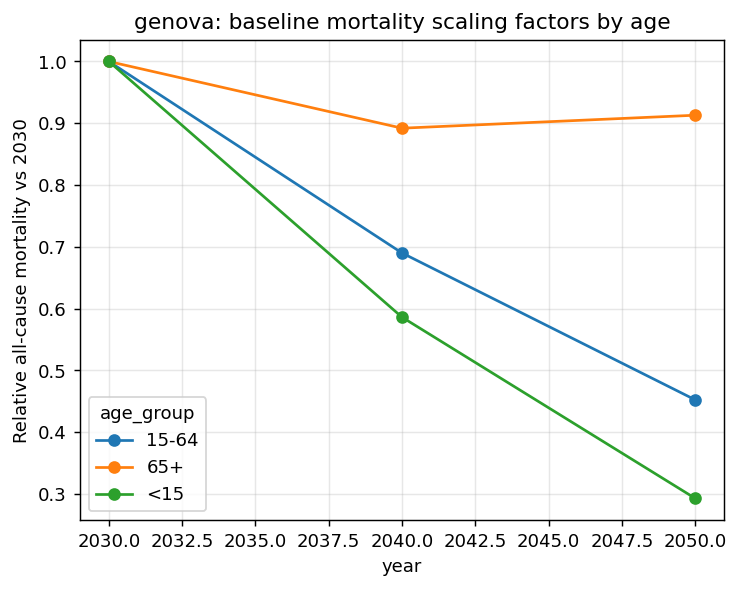

In [28]:
scale_factors.plot(marker="o")
plt.ylabel("Relative all-cause mortality vs 2030")
plt.title(f"{CITY}: baseline mortality scaling factors by age")
plt.grid(alpha=0.3)
plt.show()

Same for CLIMADA

In [29]:
# Rebuild generic CLIMADA deaths just to be explicit (same as heat_deaths_generic)

heat_deaths_generic = pd.DataFrame(climada_annual)[["15-64", "65+", "<15"]]
print("Generic annual heat deaths from CLIMADA (absolute):")
display(heat_deaths_generic)

Generic annual heat deaths from CLIMADA (absolute):


,15-64,65+,<15
2030,7.093318,61.509424,0.346224
2040,7.912337,70.247386,0.374541
2050,7.472920,65.453711,0.360051


In [30]:
# Apply baseline mortality scaling to generic CLIMADA deaths

use_scaling = True  

heat_deaths_generic_scaled = apply_baseline_scaling(
    heat_deaths_generic, scale_factors, use_scaling=use_scaling
)

print("Generic annual heat deaths after baseline scaling:")
display(heat_deaths_generic_scaled)

Generic annual heat deaths after baseline scaling:


,15-64,65+,<15
2030,7.093318,61.509424,0.346224
2040,5.460483,62.665317,0.219559
2050,3.381870,59.762250,0.105532


In [31]:
# per-100k rates for CLIMADA, before and after scaling 

def per100k_from_df(df, age_pop_by_year):
    """
    Convert absolute deaths to per-100k using year-specific populations.
    `df` is indexed by year and has columns <15, 15-64, 65+.
    """
    out = df.copy()
    for age in ["<15", "15-64", "65+"]:
        out[age] = df[age] / (age_pop_by_year[age] / 100_000.0)
    return out

heat_deaths_generic_per100k        = per100k_from_df(heat_deaths_generic,        age_pop_by_year)
heat_deaths_generic_scaled_per100k = per100k_from_df(heat_deaths_generic_scaled, age_pop_by_year)

print("Generic annual heat deaths per 100k (no baseline scaling):")
display(heat_deaths_generic_per100k)

print("Generic annual heat deaths per 100k (with baseline scaling):")
display(heat_deaths_generic_scaled_per100k)

Generic annual heat deaths per 100k (no baseline scaling):


,15-64,65+,<15
2030,2.118869,32.588266,0.652838
2040,2.688925,31.063429,0.720003
2050,2.767668,27.262607,0.656330


Generic annual heat deaths per 100k (with baseline scaling):


,15-64,65+,<15
2030,2.118869,32.588266,0.652838
2040,1.855688,27.710634,0.422070
2050,1.252508,24.892015,0.192373


In [32]:
# comparison table: CLIMADA with vs without scaling 

for age in ["<15", "15-64", "65+"]:
    cmp = pd.DataFrame({
        "no_scaling":  heat_deaths_generic[age],
        "with_scaling": heat_deaths_generic_scaled[age],
    })
    print(f"\n=== Age group {age} ===")
    display(cmp)


=== Age group <15 ===


,no_scaling,with_scaling
2030,0.346224,0.346224
2040,0.374541,0.219559
2050,0.360051,0.105532



=== Age group 15-64 ===


,no_scaling,with_scaling
2030,7.093318,7.093318
2040,7.912337,5.460483
2050,7.472920,3.381870



=== Age group 65+ ===


,no_scaling,with_scaling
2030,61.509424,61.509424
2040,70.247386,62.665317
2050,65.453711,59.762250


Now, later we can apply or not the scale when calculating the impacts

**saving**

In [33]:
from pathlib import Path

# Baseline scaling factors
sf_path = Path(INT) / f"baseline_heat_scaling_{SLUG}.csv"
scale_factors.to_csv(sf_path)
print("Saved scaling factors →", sf_path)

# Manual (city-mean) heat deaths: raw and scaled
manual_raw_path = Path(INT) / f"annual_heat_deaths_manual_{SLUG}.csv"
manual_scaled_path = Path(INT) / f"annual_heat_deaths_manual_scaled_{SLUG}.csv"

annual_by_age.to_csv(manual_raw_path)
heat_scaled.to_csv(manual_scaled_path)

print("Saved manual annual heat deaths (raw)   →", manual_raw_path)
print("Saved manual annual heat deaths (scaled)→", manual_scaled_path)

# Generic CLIMADA heat deaths: raw and scaled
generic_raw_path = INT / f"annual_heat_deaths_generic_{SLUG}.csv"
generic_scaled_path = INT / f"annual_heat_deaths_generic_scaled_{SLUG}.csv"

# making sure index is 'year' and integer, just for consistency
heat_deaths_generic.index = heat_deaths_generic.index.astype(int)
heat_deaths_generic.index.name = "year"
heat_deaths_generic.to_csv(generic_raw_path)

heat_deaths_generic_scaled.index = heat_deaths_generic_scaled.index.astype(int)
heat_deaths_generic_scaled.index.name = "year"
heat_deaths_generic_scaled.to_csv(generic_scaled_path)

print("Saved generic annual heat deaths (raw)   →", generic_raw_path)
print("Saved generic annual heat deaths (scaled)→", generic_scaled_path)

Saved scaling factors → /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/baseline_heat_scaling_genova.csv
Saved manual annual heat deaths (raw)   → /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/annual_heat_deaths_manual_genova.csv
Saved manual annual heat deaths (scaled)→ /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/annual_heat_deaths_manual_scaled_genova.csv
Saved generic annual heat deaths (raw)   → /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/annual_heat_deaths_generic_genova.csv
Saved generic annual heat deaths (scaled)→ /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/annual_heat_deaths_generic_scaled_genova.csv
